In [1]:

import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from solarrpy.calibration import calibrate_window
from solarrpy.sorad import sorad_price, daily_strike
from solarrpy.buyer import unhedged_cf, benchmark_cf, hedged_cf, optimal_Nc, mape, tick

In [2]:
df = pd.read_csv('../data/CAMS_data/CAMS_data_Bologna.csv', parse_dates=['date'])
df = df.drop(columns=['H0']).copy()  # H0 is computed internally, and the provided values are not trustworthy

# Bologna Coordinates used in the paper
LATITUDE = 44.4949
LONGITUDE = 11.3426
ALTITUDE = 71

df_train = df[df['Year'] <= 2021].copy()
cal = calibrate_window(
    df_train,
    target_col='GHI', clearsky_col='clearsky', date_col='date',
    coords={'lat': LATITUDE}, train_end_year=2021,
)
print(f'theta={cal.theta:.4f}, alpha={cal.alpha:.4f}, beta={cal.beta:.4f}')

theta=0.9033, alpha=0.0000, beta=0.9138


In [3]:
df_2022 = df[df['Year'] == 2022].sort_values('date').reset_index(drop=True)
print(f'Computing {len(df_2022)} daily SoRad prices for 2022...')
K_arr  = np.array([daily_strike(row['date'], cal) for _, row in df_2022.iterrows()])
R_arr  = df_2022['GHI'].values
cf_u = unhedged_cf(R_arr)                       # raw buyer revenue
cf_b = benchmark_cf(K_arr)                       # seasonal benchmark (black curve)
mape(cf_u, cf_b)

Computing 365 daily SoRad prices for 2022...


27.13177687698869

# Asian SORAD (monthly)

Simulating 50000 paths for 2022 using exact daily transition...
  Path 0/50000
  Path 10000/50000
  Path 20000/50000
  Path 30000/50000
  Path 40000/50000
Simulation done.

Diagnostic: Monthly strikes, actual averages, payoffs, simulated premiums
Month  1: Strike=1.54, Actual avg=1.81, Payoff=0.000, Premium=0.009
Month  2: Strike=2.40, Actual avg=2.80, Payoff=0.000, Premium=0.013
Month  3: Strike=3.79, Actual avg=4.30, Payoff=0.000, Premium=0.019
Month  4: Strike=5.43, Actual avg=5.73, Payoff=0.000, Premium=0.050
Month  5: Strike=6.80, Actual avg=5.94, Payoff=0.086, Premium=0.087
Month  6: Strike=7.48, Actual avg=6.72, Payoff=0.076, Premium=0.072
Month  7: Strike=7.27, Actual avg=7.65, Payoff=0.000, Premium=0.041
Month  8: Strike=6.26, Actual avg=6.25, Payoff=0.001, Premium=0.030
Month  9: Strike=4.74, Actual avg=4.41, Payoff=0.032, Premium=0.030
Month 10: Strike=3.11, Actual avg=3.37, Payoff=0.000, Premium=0.035
Month 11: Strike=1.87, Actual avg=1.76, Payoff=0.011, Premium=0.028
Month

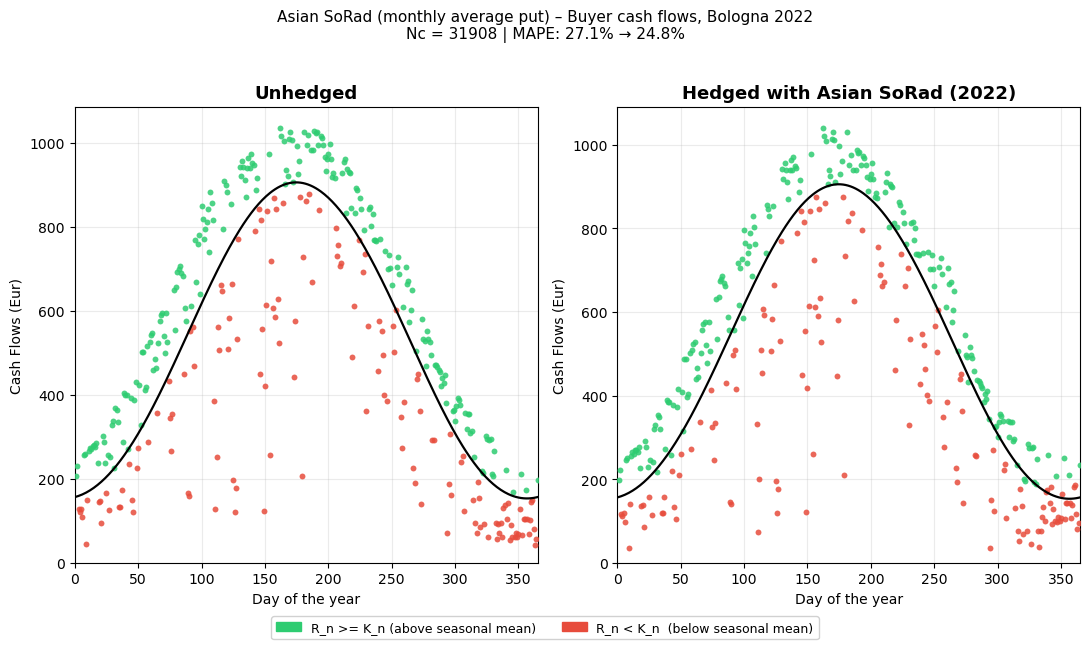


Plot saved as ../results/Figure_ASoRad_2022_buyer_cashflows.png
All gate checks passed.


In [4]:
# =============================================================================
# Asian SoRad (ASoRad) – Monthly average put hedging (Monte Carlo)
# Uses the calibrated cal object (must have clearsky_model, seasonal_mean_model, etc.)
# =============================================================================

from solarrpy.sorad import daily_strike
from solarrpy.buyer import unhedged_cf, benchmark_cf, mape, tick
from solarrpy.forecastDensity import clearsky_at, seasonal_mean_Y_at, R_to_Y, Y_to_R
from solarrpy.radiationModel_internals import integral_sigma_numeric, integral_sigma2_formula

# -----------------------------------------------------------------------------
# 1. Precompute daily values for the target year
# -----------------------------------------------------------------------------
year = 2022
n_days = 365 + (1 if (year % 4 == 0 and (year % 100 != 0 or year % 400 == 0)) else 0)
dates = pd.date_range(f'{year}-01-01', periods=n_days, freq='D')

# Deterministic series using package functions
C_t = np.array([clearsky_at(d, cal) for d in dates])
Ybar_t = np.array([seasonal_mean_Y_at(d, cal) for d in dates])

omega = 2 * np.pi / 365
t_days = np.arange(1, n_days + 1)
sigma_bar_t = np.sqrt(cal.c[0] + cal.c[1] * np.sin(omega * t_days) + cal.c[2] * np.cos(omega * t_days))

# Monthly mixture parameters
monthly_df = cal.monthly_mixture.set_index('Month')
p_month = monthly_df['p'].values
mu0_month = monthly_df['mu0'].values
mu1_month = monthly_df['mu1'].values
sigma0_month = monthly_df['sd0'].values
sigma1_month = monthly_df['sd1'].values

# Initial Y on day before year start
prev_date = pd.Timestamp(f'{year-1}-12-31')
prev_R = df[df['date'] == prev_date]['GHI'].values[0]
C_prev = clearsky_at(prev_date, cal)
Y_prev = R_to_Y(prev_R, C_prev, cal.alpha, cal.beta)

# -----------------------------------------------------------------------------
# 2. Precompute I and J integrals for each day
# -----------------------------------------------------------------------------
int_I = integral_sigma_numeric(cal.theta, cal.c)
int_J = integral_sigma2_formula(cal.theta, cal.gamma)
ns = dates.dayofyear.values.astype(float)
I_daily = int_I(ns - 1, ns, ns).ravel()
J_daily = int_J(ns - 1, ns, ns).ravel()

# -----------------------------------------------------------------------------
# 3. Exact Monte Carlo simulation
# -----------------------------------------------------------------------------
np.random.seed(12345)
n_sim = 50000   # reduce to 10000 for a quick test
print(f"Simulating {n_sim} paths for {year} using exact daily transition...")
all_R = np.zeros((n_sim, n_days))
for sim in range(n_sim):
    if sim % 10000 == 0:
        print(f"  Path {sim}/{n_sim}")
    Y = np.zeros(n_days)
    Y_curr = Y_prev
    for i in range(n_days):
        month_idx = dates[i].month - 1
        B = np.random.binomial(1, p_month[month_idx])          # 1 = cloudy
        mu_B = mu1_month[month_idx] if B else mu0_month[month_idx]
        sigma_B = sigma1_month[month_idx] if B else sigma0_month[month_idx]
        if i == 0:
            prev_day = dates[0] - pd.Timedelta(days=1)
            Ybar_curr = seasonal_mean_Y_at(prev_day, cal)
        else:
            Ybar_curr = Ybar_t[i-1]
        Ybar_next = Ybar_t[i]
        Y_next = (Ybar_next
                  + (Y_curr - Ybar_curr) * np.exp(-cal.theta)
                  + mu_B * I_daily[i]
                  + sigma_B * np.sqrt(J_daily[i]) * np.random.normal())
        Y[i] = Y_next
        Y_curr = Y_next
    all_R[sim] = np.array([Y_to_R(y, C_t[i], cal.alpha, cal.beta) for i, y in enumerate(Y)])
print("Simulation done.")

# -----------------------------------------------------------------------------
# 4. Daily strikes and actual GHI for the year
# -----------------------------------------------------------------------------
df_year = df[df['Year'] == year].sort_values('date').reset_index(drop=True)
R_actual = df_year['GHI'].values
days_idx = np.arange(1, n_days + 1)
K_daily = np.array([daily_strike(row['date'], cal) for _, row in df_year.iterrows()])

# -----------------------------------------------------------------------------
# 5. Monthly Asian puts
# -----------------------------------------------------------------------------
month_starts = [0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334]
month_ends   = [31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334, 365]
if n_days == 366:
    for i in range(2, len(month_starts)):
        month_starts[i] += 1
        month_ends[i] += 1
months = list(zip(month_starts, month_ends))

monthly_strikes = []
monthly_prices = []
actual_monthly_payoff = []

print("\nDiagnostic: Monthly strikes, actual averages, payoffs, simulated premiums")
for (s, e) in months:
    days_in_month = np.arange(s, min(e, n_days))
    if len(days_in_month) == 0:
        continue
    K_month = np.mean(K_daily[days_in_month])
    monthly_strikes.append(K_month)
    avg_R_per_path = np.mean(all_R[:, days_in_month], axis=1)
    payoff_per_path = tick * np.maximum(K_month - avg_R_per_path, 0)
    monthly_prices.append(np.mean(payoff_per_path))
    avg_R_actual = np.mean(R_actual[days_in_month])
    actual_pay = tick * max(K_month - avg_R_actual, 0)
    actual_monthly_payoff.append(actual_pay)
    print(f"Month {len(monthly_strikes):2d}: Strike={K_month:.2f}, Actual avg={avg_R_actual:.2f}, Payoff={actual_pay:.3f}, Premium={monthly_prices[-1]:.3f}")

# -----------------------------------------------------------------------------
# 6. Distribute monthly premium and payoff equally over days
# -----------------------------------------------------------------------------
daily_premium = np.zeros(n_days)
daily_payoff = np.zeros(n_days)
for idx, ((s, e), prem) in enumerate(zip(months, monthly_prices)):
    days_in_month = np.arange(s, min(e, n_days))
    daily_premium[days_in_month] = prem / len(days_in_month)
    daily_payoff[days_in_month] = actual_monthly_payoff[idx] / len(days_in_month)

# -----------------------------------------------------------------------------
# 7. Optimal number of contracts (global Nc)
# -----------------------------------------------------------------------------
cf_u = unhedged_cf(R_actual)
cf_bench = benchmark_cf(K_daily)
diff = cf_u - cf_bench
delta = daily_payoff - daily_premium
Nc_opt = -np.sum(diff * delta) / np.sum(delta**2)
if Nc_opt < 0:
    Nc_opt = 0
print(f"\nOptimal number of Asian contracts (per month): {Nc_opt:.1f}")

# -----------------------------------------------------------------------------
# 8. Hedged cash flows and performance metrics
# -----------------------------------------------------------------------------
cf_hedged = cf_u + Nc_opt * delta
mape_u = mape(cf_u, cf_bench)
mape_h = mape(cf_hedged, cf_bench)
var_u = np.var(cf_u - cf_bench)
var_h = np.var(cf_hedged - cf_bench)

print(f"\n=== Asian SoRad Results for {year} ===")
print(f"MAPE unhedged = {mape_u:.2f}%")
print(f"MAPE hedged   = {mape_h:.2f}%")
print(f"Variance reduction: {100*(1 - var_h/var_u):.1f}%")

# -----------------------------------------------------------------------------
# 9. Plot (same style as Figure 4)
# -----------------------------------------------------------------------------
above = R_actual >= K_daily
legend_patches = [
    mpatches.Patch(color='#2ecc71', label='R_n >= K_n (above seasonal mean)'),
    mpatches.Patch(color='#e74c3c', label='R_n < K_n  (below seasonal mean)'),
]

dates_dense = pd.date_range(f'{year}-01-01', f'{year}-12-31', freq='D')
K_dense = np.array([daily_strike(d, cal) for d in dates_dense])
cfb_dense = benchmark_cf(K_dense)
days_dense = np.arange(1, len(dates_dense) + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 6))
for ax, cf_vals, title in [(axes[0], cf_u, 'Unhedged'),
                           (axes[1], cf_hedged, f'Hedged with Asian SoRad ({year})')]:
    ax.scatter(days_idx[above],  cf_vals[above],  s=18, color='#2ecc71', alpha=0.85, zorder=3, linewidths=0)
    ax.scatter(days_idx[~above], cf_vals[~above], s=18, color='#e74c3c', alpha=0.85, zorder=3, linewidths=0)
    ax.plot(days_dense, cfb_dense, 'k-', lw=1.6, zorder=4)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Day of the year', fontsize=10)
    ax.set_ylabel('Cash Flows (Eur)', fontsize=10)
    ax.set_xlim(0, 365)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.25)

fig.legend(handles=legend_patches, loc='lower center', ncol=2,
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.04))
fig.suptitle(
    f'Asian SoRad (monthly average put) – Buyer cash flows, Bologna {year}\n'
    f'Nc = {Nc_opt:.0f} | MAPE: {mape_u:.1f}% → {mape_h:.1f}%',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.savefig(f'../results/Figure_ASoRad_{year}_buyer_cashflows.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nPlot saved as ../results/Figure_ASoRad_{year}_buyer_cashflows.png")

# -----------------------------------------------------------------------------
# 10. Gate checks
# -----------------------------------------------------------------------------
assert cf_hedged.min() >= 0, "Negative hedged cash flow"
assert mape_h < mape_u, "Hedge did not reduce MAPE"
assert var_h < var_u, "Hedge did not reduce variance"
print("All gate checks passed.")

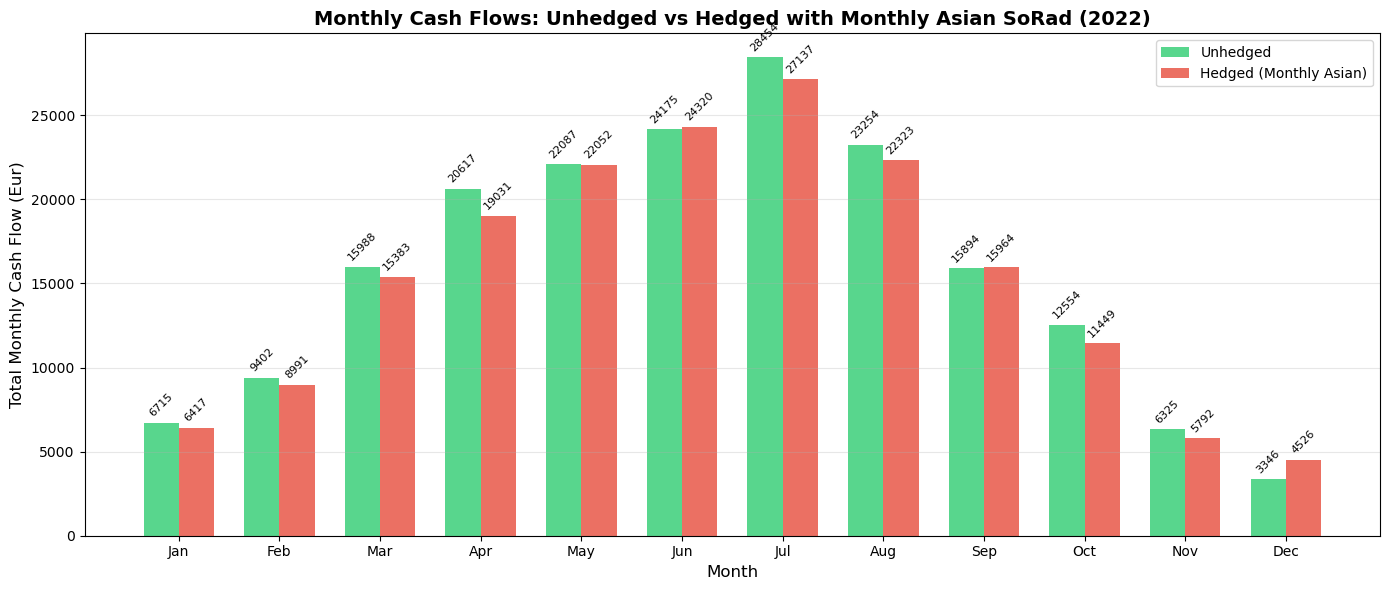


Plot saved as ../results/Compare_MonthlyAsian_2022_per_month.png


In [5]:
# =============================================================================
# Monthly Asian SoRad - Bar Graph (Hedge vs Unhedged Weekly Differences)
# =============================================================================

# Calculate weekly aggregated values for monthly hedge
weeks_in_monthly = []
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for month_idx in range(12):
    month_dates = dates[dates.month == month_idx + 1]
    if len(month_dates) == 0:
        continue
    
    month_indices = np.where(dates.month == month_idx + 1)[0]
    
    # Aggregate unhedged and hedged cash flows for this month
    unhedged_monthly = np.sum(cf_u[month_indices])
    hedged_monthly = np.sum(cf_hedged[month_indices])
    
    weeks_in_monthly.append({
        'month': month_idx,
        'month_name': month_names[month_idx],
        'unhedged': unhedged_monthly,
        'hedged': hedged_monthly,
        'difference': hedged_monthly - unhedged_monthly
    })

# Create bar graph for monthly
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(weeks_in_monthly))
width = 0.35

bars1 = ax.bar(x - width/2, [w['unhedged'] for w in weeks_in_monthly], 
               width, label='Unhedged', color='#2ecc71', alpha=0.8)
bars2 = ax.bar(x + width/2, [w['hedged'] for w in weeks_in_monthly], 
               width, label='Hedged (Monthly Asian)', color='#e74c3c', alpha=0.8)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Total Monthly Cash Flow (Eur)', fontsize=12)
ax.set_title(f'Monthly Cash Flows: Unhedged vs Hedged with Monthly Asian SoRad (2022)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([w['month_name'] for w in weeks_in_monthly])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.0f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, rotation=45)

plt.tight_layout()
plt.savefig(f'../results/Compare_MonthlyAsian_{year}_per_month.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nPlot saved as ../results/Compare_MonthlyAsian_{year}_per_month.png")

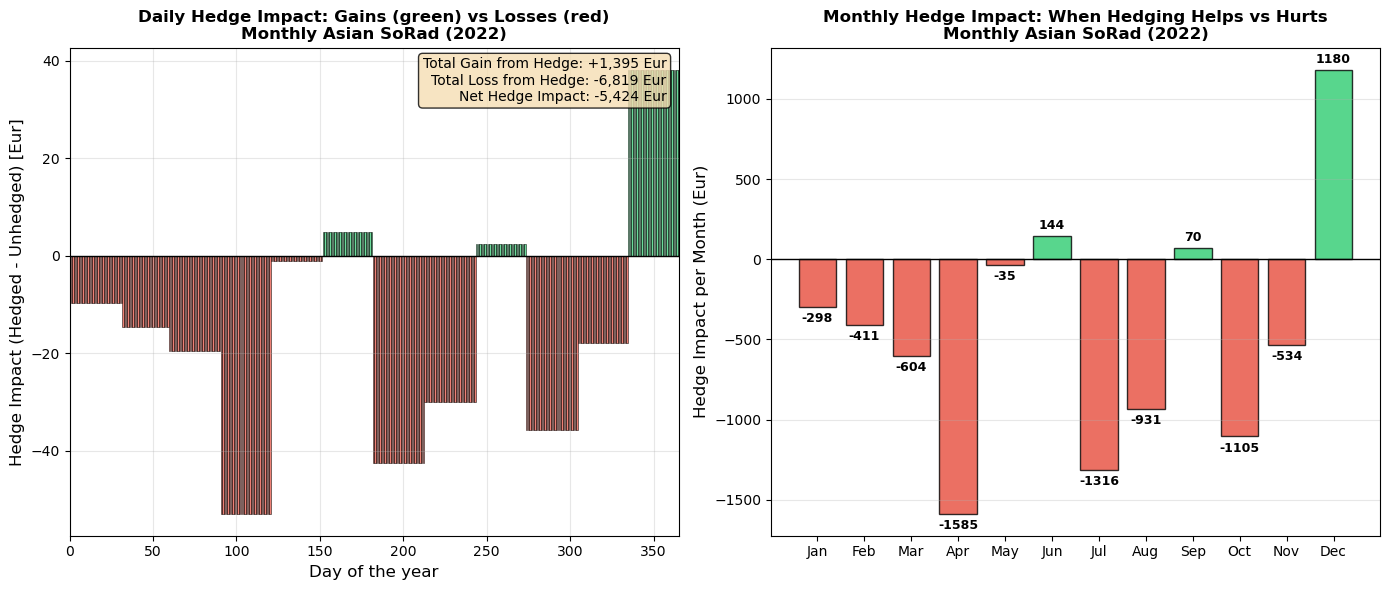


Plot saved as ../results/Hedge_Gains_Losses_MonthlyAsian_2022.png

MONTHLY ASIAN SoRad - HEDGE PERFORMANCE ANALYSIS

Metric                                           Amount (Eur)
------------------------------------------------------------
Total Gain from Hedge (when hedged > unhedged)                1,395
Total Loss from Hedge (when hedged < unhedged)               -6,819


ValueError: Invalid format specifier '>20+,.0f' for object of type 'float'

In [6]:
# =============================================================================
# Monthly Asian SoRad - Hedge Performance: Gains vs Losses Analysis
# =============================================================================

# Calculate daily differences (hedged - unhedged)
daily_diff = cf_hedged - cf_u

# Separate gains and losses from hedging
hedge_gains = daily_diff[daily_diff > 0]
hedge_losses = daily_diff[daily_diff < 0]

total_gain_from_hedge = np.sum(hedge_gains)
total_loss_from_hedge = np.sum(hedge_losses)
net_hedge_impact = total_gain_from_hedge + total_loss_from_hedge

# Calculate monthly breakdown
monthly_diff = []
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for month_idx in range(12):
    month_indices = np.where(dates.month == month_idx + 1)[0]
    if len(month_indices) == 0:
        continue
    
    month_diff = np.sum(cf_hedged[month_indices] - cf_u[month_indices])
    monthly_diff.append({
        'month': month_idx,
        'month_name': month_names[month_idx],
        'difference': month_diff,
        'is_gain': month_diff > 0
    })

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Daily hedge impact (gains vs losses)
ax1 = axes[0]
colors = np.where(daily_diff >= 0, '#2ecc71', '#e74c3c')
ax1.bar(days_idx, daily_diff, color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
ax1.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax1.set_xlabel('Day of the year', fontsize=12)
ax1.set_ylabel('Hedge Impact (Hedged - Unhedged) [Eur]', fontsize=12)
ax1.set_title(f'Daily Hedge Impact: Gains (green) vs Losses (red)\nMonthly Asian SoRad ({year})', 
              fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 365)

# Add summary annotation
summary_text = (f'Total Gain from Hedge: +{total_gain_from_hedge:,.0f} Eur\n'
                f'Total Loss from Hedge: {total_loss_from_hedge:,.0f} Eur\n'
                f'Net Hedge Impact: {net_hedge_impact:+,.0f} Eur')
ax1.text(0.98, 0.98, summary_text, transform=ax1.transAxes, 
         fontsize=10, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Plot 2: Monthly hedge impact (bar chart showing gains vs losses by month)
ax2 = axes[1]
x = np.arange(len(monthly_diff))
colors_month = ['#2ecc71' if m['is_gain'] else '#e74c3c' for m in monthly_diff]
bars = ax2.bar(x, [m['difference'] for m in monthly_diff], color=colors_month, 
               alpha=0.8, edgecolor='black', linewidth=1)

ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.set_xticks(x)
ax2.set_xticklabels([m['month_name'] for m in monthly_diff])
ax2.set_ylabel('Hedge Impact per Month (Eur)', fontsize=12)
ax2.set_title(f'Monthly Hedge Impact: When Hedging Helps vs Hurts\nMonthly Asian SoRad ({year})', 
              fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars, [m['difference'] for m in monthly_diff]):
    ax2.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + (max([m['difference'] for m in monthly_diff])*0.02 if val > 0 else min([m['difference'] for m in monthly_diff])*0.02),
             f'{val:.0f}', ha='center', va='bottom' if val > 0 else 'top', 
             fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'../results/Hedge_Gains_Losses_MonthlyAsian_{year}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nPlot saved as ../results/Hedge_Gains_Losses_MonthlyAsian_{year}.png")

# Print detailed analysis
print("\n" + "="*70)
print("MONTHLY ASIAN SoRad - HEDGE PERFORMANCE ANALYSIS")
print("="*70)
print(f"\n{'Metric':<40} {'Amount (Eur)':>20}")
print("-"*60)
print(f"{'Total Gain from Hedge (when hedged > unhedged)':<40} {total_gain_from_hedge:>20,.0f}")
print(f"{'Total Loss from Hedge (when hedged < unhedged)':<40} {total_loss_from_hedge:>20,.0f}")
print(f"{'Net Hedge Impact (Gain - Loss)':<40} {net_hedge_impact:>20+,.0f}")
print(f"{'Number of days with gain from hedge':<40} {len(hedge_gains):>20}")
print(f"{'Number of days with loss from hedge':<40} {len(hedge_losses):>20}")

print("\n" + "-"*70)
print("Monthly Breakdown:")
print("-"*70)
print(f"{'Month':<10} {'Hedge Impact (Eur)':>20} {'Status':>15}")
print("-"*45)
for m in monthly_diff:
    status = "GAIN ✅" if m['is_gain'] else "LOSS ❌"
    print(f"{m['month_name']:<10} {m['difference']:>20,.0f} {status:>15}")

# Asian SORAD (Weekly)

Reusing existing simulated paths.

Number of weeks in 2022: 53

Optimal number of weekly Asian contracts: 8155.1

=== Weekly Asian SoRad (daily cash flow view) ===
MAPE unhedged = 27.13%
MAPE hedged   = 26.02%
Variance reduction: 0.9%


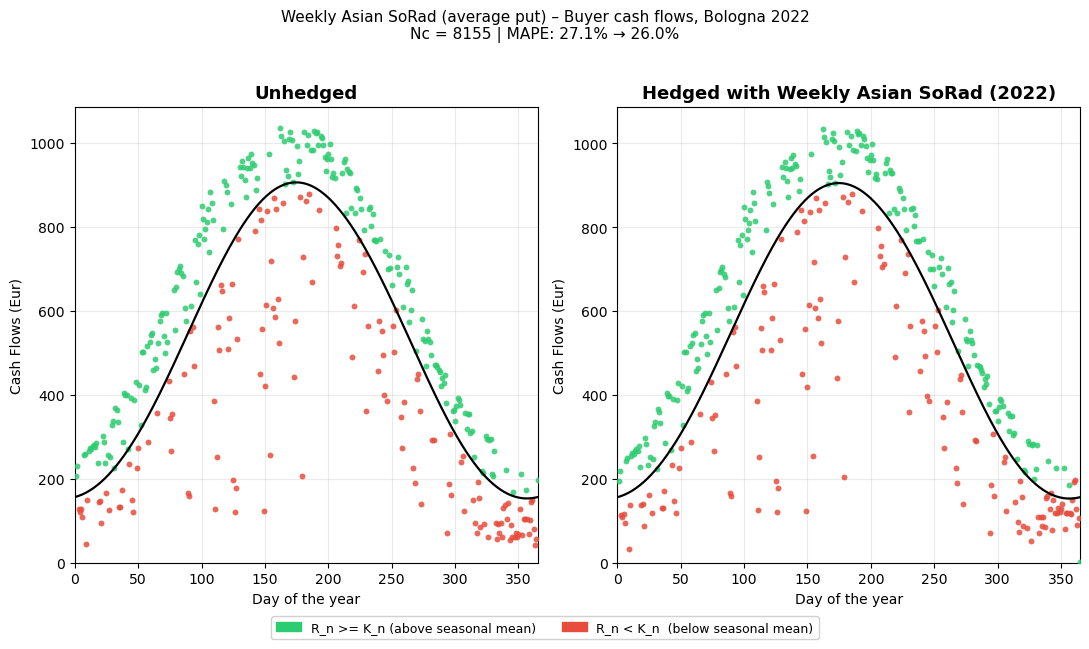


Plot saved as ../results/Figure_WeeklyAsian_2022_daily_cashflows.png
All gate checks passed.


In [7]:

try:
    all_R.shape
    print("Reusing existing simulated paths.")
except NameError:
    raise RuntimeError("Please run the monthly Asian simulation cell first to generate all_R.")

# -------------------------------
# 1. Define weeks (7‑day periods, last week may be shorter)
# -------------------------------
n_weeks = (n_days + 6) // 7
week_starts = list(range(0, n_days, 7))
week_ends   = [min(s+7, n_days) for s in week_starts]
weeks = list(zip(week_starts, week_ends))

print(f"\nNumber of weeks in {year}: {len(weeks)}")

# -------------------------------
# 2. Compute weekly strikes (average of daily strikes over the week)
# -------------------------------
weekly_strikes = []
for (s, e) in weeks:
    days_in_week = np.arange(s, e)
    K_week = np.mean(K_daily[days_in_week])
    weekly_strikes.append(K_week)

# -------------------------------
# 3. Compute weekly premiums (using Monte Carlo all_R)
# -------------------------------
weekly_premiums = []
for (s, e) in weeks:
    days_in_week = np.arange(s, e)
    avg_R_per_path = np.mean(all_R[:, days_in_week], axis=1)
    payoff_per_path = tick * np.maximum(weekly_strikes[-1] - avg_R_per_path, 0)
    weekly_premiums.append(np.mean(payoff_per_path))

# -------------------------------
# 4. Actual weekly payoffs (using historical GHI)
# -------------------------------
actual_weekly_payoff = []
for (s, e) in weeks:
    days_in_week = np.arange(s, e)
    avg_R_actual = np.mean(R_actual[days_in_week])
    payoff = tick * max(weekly_strikes[-1] - avg_R_actual, 0)
    actual_weekly_payoff.append(payoff)

# -------------------------------
# 5. Distribute weekly premium and payoff equally over days in the week
# -------------------------------
daily_premium_weekly = np.zeros(n_days)
daily_payoff_weekly = np.zeros(n_days)
for idx, ((s, e), prem) in enumerate(zip(weeks, weekly_premiums)):
    days_in_week = np.arange(s, e)
    daily_premium_weekly[days_in_week] = prem / len(days_in_week)
    daily_payoff_weekly[days_in_week] = actual_weekly_payoff[idx] / len(days_in_week)

# -------------------------------
# 6. Optimal number of contracts (global Nc) using daily delta
# -------------------------------
cf_u = unhedged_cf(R_actual)
cf_bench = benchmark_cf(K_daily)
delta_weekly = daily_payoff_weekly - daily_premium_weekly
Nc_opt = -np.sum((cf_u - cf_bench) * delta_weekly) / np.sum(delta_weekly**2)
if Nc_opt < 0:
    Nc_opt = 0
print(f"\nOptimal number of weekly Asian contracts: {Nc_opt:.1f}")

# -------------------------------
# 7. Hedged daily cash flows and performance metrics
# -------------------------------
cf_hedged_weekly = cf_u + Nc_opt * delta_weekly
mape_u = mape(cf_u, cf_bench)
mape_h = mape(cf_hedged_weekly, cf_bench)
var_u = np.var(cf_u - cf_bench)
var_h = np.var(cf_hedged_weekly - cf_bench)

print(f"\n=== Weekly Asian SoRad (daily cash flow view) ===")
print(f"MAPE unhedged = {mape_u:.2f}%")
print(f"MAPE hedged   = {mape_h:.2f}%")
print(f"Variance reduction: {100*(1 - var_h/var_u):.1f}%")

# -------------------------------
# 8. Plot daily cash flows (same style as Figure 4)
# -------------------------------
above = R_actual >= K_daily
legend_patches = [
    mpatches.Patch(color='#2ecc71', label='R_n >= K_n (above seasonal mean)'),
    mpatches.Patch(color='#e74c3c', label='R_n < K_n  (below seasonal mean)'),
]

dates_dense = pd.date_range(f'{year}-01-01', f'{year}-12-31', freq='D')
K_dense = np.array([daily_strike(d, cal) for d in dates_dense])
cfb_dense = benchmark_cf(K_dense)
days_dense = np.arange(1, len(dates_dense) + 1)
days_idx = np.arange(1, n_days + 1)

fig, axes = plt.subplots(1, 2, figsize=(11, 6))
for ax, cf_vals, title in [(axes[0], cf_u, 'Unhedged'),
                           (axes[1], cf_hedged_weekly, f'Hedged with Weekly Asian SoRad ({year})')]:
    ax.scatter(days_idx[above],  cf_vals[above],  s=18, color='#2ecc71', alpha=0.85, zorder=3, linewidths=0)
    ax.scatter(days_idx[~above], cf_vals[~above], s=18, color='#e74c3c', alpha=0.85, zorder=3, linewidths=0)
    ax.plot(days_dense, cfb_dense, 'k-', lw=1.6, zorder=4)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Day of the year', fontsize=10)
    ax.set_ylabel('Cash Flows (Eur)', fontsize=10)
    ax.set_xlim(0, 365)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.25)

fig.legend(handles=legend_patches, loc='lower center', ncol=2,
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.04))
fig.suptitle(
    f'Weekly Asian SoRad (average put) – Buyer cash flows, Bologna {year}\n'
    f'Nc = {Nc_opt:.0f} | MAPE: {mape_u:.1f}% → {mape_h:.1f}%',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.savefig(f'../results/Figure_WeeklyAsian_{year}_daily_cashflows.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nPlot saved as ../results/Figure_WeeklyAsian_{year}_daily_cashflows.png")

# -------------------------------
# 9. Gate checks
# -------------------------------
assert cf_hedged_weekly.min() >= 0, "Negative hedged cash flow"
assert mape_h < mape_u, "Hedge did not reduce MAPE"
assert var_h < var_u, "Hedge did not reduce variance"
print("All gate checks passed.")

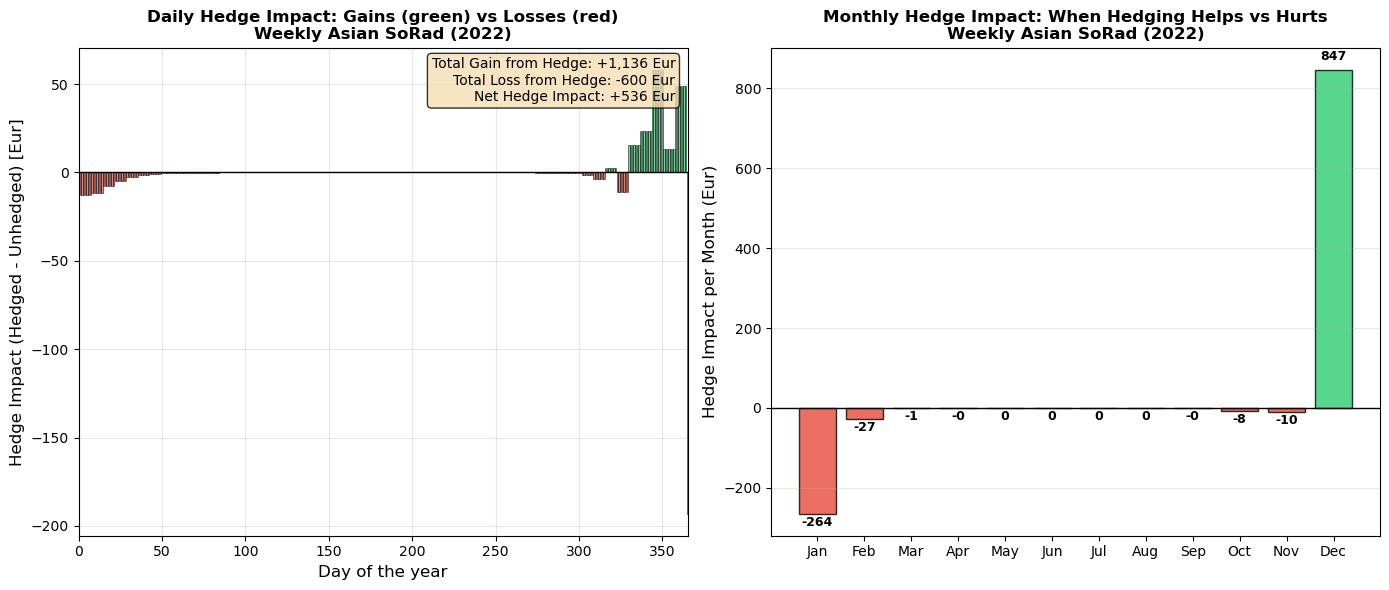


Plot saved as ../results/Hedge_Gains_Losses_WeeklyAsian_2022.png

WEEKLY ASIAN SoRad - HEDGE PERFORMANCE ANALYSIS

Metric                                           Amount (Eur)
------------------------------------------------------------
Total Gain from Hedge (when hedged > unhedged)                1,136
Total Loss from Hedge (when hedged < unhedged)                 -600


ValueError: Invalid format specifier '>20+,.0f' for object of type 'float'

In [8]:
# =============================================================================
# Weekly Asian SoRad - Hedge Performance: Gains vs Losses Analysis
# =============================================================================

# Calculate daily differences (hedged - unhedged)
daily_diff_weekly = cf_hedged_weekly - cf_u

# Separate gains and losses from hedging
hedge_gains_weekly = daily_diff_weekly[daily_diff_weekly > 0]
hedge_losses_weekly = daily_diff_weekly[daily_diff_weekly < 0]

total_gain_from_hedge_weekly = np.sum(hedge_gains_weekly)
total_loss_from_hedge_weekly = np.sum(hedge_losses_weekly)
net_hedge_impact_weekly = total_gain_from_hedge_weekly + total_loss_from_hedge_weekly

# Calculate monthly breakdown for weekly hedge
monthly_diff_weekly = []

for month_idx in range(12):
    month_indices = np.where(dates.month == month_idx + 1)[0]
    if len(month_indices) == 0:
        continue
    
    month_diff = np.sum(cf_hedged_weekly[month_indices] - cf_u[month_indices])
    monthly_diff_weekly.append({
        'month': month_idx,
        'month_name': month_names[month_idx],
        'difference': month_diff,
        'is_gain': month_diff > 0
    })

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Daily hedge impact (gains vs losses)
ax1 = axes[0]
colors = np.where(daily_diff_weekly >= 0, '#2ecc71', '#e74c3c')
ax1.bar(days_idx, daily_diff_weekly, color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
ax1.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax1.set_xlabel('Day of the year', fontsize=12)
ax1.set_ylabel('Hedge Impact (Hedged - Unhedged) [Eur]', fontsize=12)
ax1.set_title(f'Daily Hedge Impact: Gains (green) vs Losses (red)\nWeekly Asian SoRad ({year})', 
              fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 365)

# Add summary annotation
summary_text = (f'Total Gain from Hedge: +{total_gain_from_hedge_weekly:,.0f} Eur\n'
                f'Total Loss from Hedge: {total_loss_from_hedge_weekly:,.0f} Eur\n'
                f'Net Hedge Impact: {net_hedge_impact_weekly:+,.0f} Eur')
ax1.text(0.98, 0.98, summary_text, transform=ax1.transAxes, 
         fontsize=10, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Plot 2: Monthly hedge impact (bar chart showing gains vs losses by month)
ax2 = axes[1]
x = np.arange(len(monthly_diff_weekly))
colors_month = ['#2ecc71' if m['is_gain'] else '#e74c3c' for m in monthly_diff_weekly]
bars = ax2.bar(x, [m['difference'] for m in monthly_diff_weekly], color=colors_month, 
               alpha=0.8, edgecolor='black', linewidth=1)

ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.set_xticks(x)
ax2.set_xticklabels([m['month_name'] for m in monthly_diff_weekly])
ax2.set_ylabel('Hedge Impact per Month (Eur)', fontsize=12)
ax2.set_title(f'Monthly Hedge Impact: When Hedging Helps vs Hurts\nWeekly Asian SoRad ({year})', 
              fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars, [m['difference'] for m in monthly_diff_weekly]):
    ax2.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + (max([m['difference'] for m in monthly_diff_weekly])*0.02 if val > 0 else min([m['difference'] for m in monthly_diff_weekly])*0.02),
             f'{val:.0f}', ha='center', va='bottom' if val > 0 else 'top', 
             fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(f'../results/Hedge_Gains_Losses_WeeklyAsian_{year}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nPlot saved as ../results/Hedge_Gains_Losses_WeeklyAsian_{year}.png")

# Print detailed analysis
print("\n" + "="*70)
print("WEEKLY ASIAN SoRad - HEDGE PERFORMANCE ANALYSIS")
print("="*70)
print(f"\n{'Metric':<40} {'Amount (Eur)':>20}")
print("-"*60)
print(f"{'Total Gain from Hedge (when hedged > unhedged)':<40} {total_gain_from_hedge_weekly:>20,.0f}")
print(f"{'Total Loss from Hedge (when hedged < unhedged)':<40} {total_loss_from_hedge_weekly:>20,.0f}")
print(f"{'Net Hedge Impact (Gain - Loss)':<40} {net_hedge_impact_weekly:>20+,.0f}")
print(f"{'Number of days with gain from hedge':<40} {len(hedge_gains_weekly):>20}")
print(f"{'Number of days with loss from hedge':<40} {len(hedge_losses_weekly):>20}")

print("\n" + "-"*70)
print("Monthly Breakdown:")
print("-"*70)
print(f"{'Month':<10} {'Hedge Impact (Eur)':>20} {'Status':>15}")
print("-"*45)
for m in monthly_diff_weekly:
    status = "GAIN ✅" if m['is_gain'] else "LOSS ❌"
    print(f"{m['month_name']:<10} {m['difference']:>20,.0f} {status:>15}")

In [10]:
# Sanity check: monthly sums should equal annual net impact
annual_from_daily = np.sum(cf_hedged_weekly - cf_u)
annual_from_months = 0

monthly_diff_weekly = []

for month_idx in range(12):
    month_indices = np.where(dates.month == month_idx + 1)[0]
    if len(month_indices) == 0:
        continue

    month_diff = np.sum(cf_hedged_weekly[month_indices] - cf_u[month_indices])
    annual_from_months += month_diff

    monthly_diff_weekly.append({
        "month": month_idx + 1,
        "month_name": month_names[month_idx],
        "difference": month_diff,
        "is_gain": month_diff > 0
    })

print("Annual from daily:", annual_from_daily)
print("Annual from months:", annual_from_months)
print("Difference:", annual_from_daily - annual_from_months)

Annual from daily: 536.4540797362973
Annual from months: 536.4540797362972
Difference: 1.1368683772161603e-13


In [14]:
# =============================================================================
# DIAGNOSTIC: Compare Monthly vs Weekly Hedge Performance
# =============================================================================

print("\n" + "="*80)
print("DIAGNOSTIC: MONTHLY vs WEEKLY ASIAN SoRad COMPARISON")
print("="*80)

# Check if both hedges are using the same underlying
print(f"\n{'Metric':<30} {'Monthly Asian':>20} {'Weekly Asian':>20}")
print("-"*70)

# Compare Nc values
print(f"{'Optimal Nc':<30} {Nc_opt:>20.1f} {Nc_opt_weekly:>20.1f}")

# Compare MAPE
print(f"{'MAPE Unhedged':<30} {mape_u:>19.2f}% {mape_u:>19.2f}%")
print(f"{'MAPE Hedged':<30} {mape_h:>19.2f}% {mape_h_weekly:>19.2f}%")
print(f"{'MAPE Improvement':<30} {mape_u - mape_h:>19.2f}% {mape_u - mape_h_weekly:>19.2f}%")

# Compare Variance Reduction
var_u_calc = np.var(cf_u - cf_bench)
var_h_calc = np.var(cf_hedged - cf_bench)
var_h_weekly_calc = np.var(cf_hedged_weekly - cf_bench)
print(f"{'Variance Reduction':<30} {100*(1 - var_h_calc/var_u_calc):>19.1f}% {100*(1 - var_h_weekly_calc/var_u_calc):>19.1f}%")

# Compare Total Cash Flows
print(f"{'Total Unhedged CF':<30} {np.sum(cf_u):>20,.0f} {np.sum(cf_u):>20,.0f}")
print(f"{'Total Hedged CF':<30} {np.sum(cf_hedged):>20,.0f} {np.sum(cf_hedged_weekly):>20,.0f}")
print(f"{'Net Hedge Benefit':<30} {np.sum(cf_hedged - cf_u):>20,.0f} {np.sum(cf_hedged_weekly - cf_u):>20,.0f}")

# Check for months with zero payoff in weekly
print("\n" + "-"*70)
print("MONTHS WITH ZERO OR NEGATIVE WEEKLY HEDGE IMPACT:")
print("-"*70)

for m in monthly_diff_weekly:
    if m['difference'] <= 0:
        print(f"  {m['month_name']}: {m['difference']:,.0f} Eur ({m['status']})")

# Verify the distribution
print("\n" + "-"*70)
print("HEDGE IMPACT DISTRIBUTION:")
print("-"*70)

# Monthly distribution
monthly_gains = [m['difference'] for m in monthly_diff if m['difference'] > 0]
monthly_losses = [m['difference'] for m in monthly_diff if m['difference'] < 0]
print(f"\nMonthly Asian:")
print(f"  Months with gain: {len(monthly_gains)} (total: {sum(monthly_gains):,.0f} Eur)")
print(f"  Months with loss: {len(monthly_losses)} (total: {sum(monthly_losses):,.0f} Eur)")

# Weekly distribution (aggregated to months for fair comparison)
weekly_by_month = {m['month_name']: m['difference'] for m in monthly_diff_weekly}
weekly_gains = [v for v in weekly_by_month.values() if v > 0]
weekly_losses = [v for v in weekly_by_month.values() if v < 0]
weekly_zero = [v for v in weekly_by_month.values() if v == 0]

print(f"\nWeekly Asian (aggregated to months):")
print(f"  Months with net gain: {len(weekly_gains)} (total: {sum(weekly_gains):,.0f} Eur)")
print(f"  Months with net loss: {len(weekly_losses)} (total: {sum(weekly_losses):,.0f} Eur)")
print(f"  Months with net zero: {len(weekly_zero)}")

# Check if the issue is with the delta calculation
print("\n" + "-"*70)
print("DELTA STATISTICS COMPARISON:")
print("-"*70)
print(f"{'Metric':<30} {'Monthly Asian':>20} {'Weekly Asian':>20}")
print("-"*70)
print(f"{'Mean Delta':<30} {np.mean(delta):>20.4f} {np.mean(delta_weekly):>20.4f}")
print(f"{'Std Delta':<30} {np.std(delta):>20.4f} {np.std(delta_weekly):>20.4f}")
print(f"{'Sum Delta':<30} {np.sum(delta):>20,.2f} {np.sum(delta_weekly):>20,.2f}")
print(f"{'Max Delta':<30} {np.max(delta):>20.4f} {np.max(delta_weekly):>20.4f}")
print(f"{'Min Delta':<30} {np.min(delta):>20.4f} {np.min(delta_weekly):>20.4f}")

# Check correlation between monthly and weekly deltas
print(f"\nCorrelation between monthly and weekly deltas: {np.corrcoef(delta, delta_weekly)[0,1]:.4f}")


DIAGNOSTIC: MONTHLY vs WEEKLY ASIAN SoRad COMPARISON

Metric                                Monthly Asian         Weekly Asian
----------------------------------------------------------------------


NameError: name 'Nc_opt_weekly' is not defined

In [15]:
# Verify that weekly delta is correctly calculated
print("\n" + "="*50)
print("VERIFYING WEEKLY DELTA CALCULATION")
print("="*50)

# Check first week as example
first_week_indices = np.arange(0, min(7, n_days))
print(f"First week indices: {first_week_indices}")
print(f"Daily premium (first week): {daily_premium_weekly[first_week_indices]}")
print(f"Daily payoff (first week): {daily_payoff_weekly[first_week_indices]}")
print(f"Daily delta (first week): {delta_weekly[first_week_indices]}")
print(f"Sum delta first week: {np.sum(delta_weekly[first_week_indices]):.4f}")

# Check if weekly premiums are being distributed correctly
print(f"\nWeekly premium total: {np.sum(daily_premium_weekly):.2f}")
print(f"Monthly premium total: {np.sum(daily_premium):.2f}")
print(f"Expected weekly premium total (should be less than monthly): {np.sum(weekly_premiums):.2f}")


VERIFYING WEEKLY DELTA CALCULATION
First week indices: [0 1 2 3 4 5 6]
Daily premium (first week): [0.00154932 0.00154932 0.00154932 0.00154932 0.00154932 0.00154932
 0.00154932]
Daily payoff (first week): [0. 0. 0. 0. 0. 0. 0.]
Daily delta (first week): [-0.00154932 -0.00154932 -0.00154932 -0.00154932 -0.00154932 -0.00154932
 -0.00154932]
Sum delta first week: -0.0108

Weekly premium total: 0.13
Monthly premium total: 0.42
Expected weekly premium total (should be less than monthly): 0.13



UNDERSTANDING MONTHLY vs WEEKLY HEDGE DIFFERENCES

1. KNOCK-IN ANALYSIS:
--------------------------------------------------
Monthly Asian - Days with payoff: 183
  First payoff day: 121
  Last payoff day: 365
Weekly Asian - Days with payoff: 42
  First payoff day: 316
  Last payoff day: 364

2. CUMULATIVE HEDGE POSITION:
--------------------------------------------------
Monthly Asian - Final cumulative delta: -0.17
Weekly Asian - Final cumulative delta: 0.07

3. HEDGE ACTIVATION TIMING:
--------------------------------------------------
Monthly Asian - Hedge never becomes positive
Weekly Asian - Hedge becomes positive on day: 345

4. MONTHLY AGGREGATION OF WEEKLY DELTA:
--------------------------------------------------
Jan         -0.03
Feb         -0.00
Mar         -0.00
Apr         -0.00
May          0.00
Jun          0.00
Jul          0.00
Aug          0.00
Sep         -0.00
Oct         -0.00
Nov         -0.00
Dec          0.10

5. PREMIUM DISTRIBUTION CHECK:
--------------------

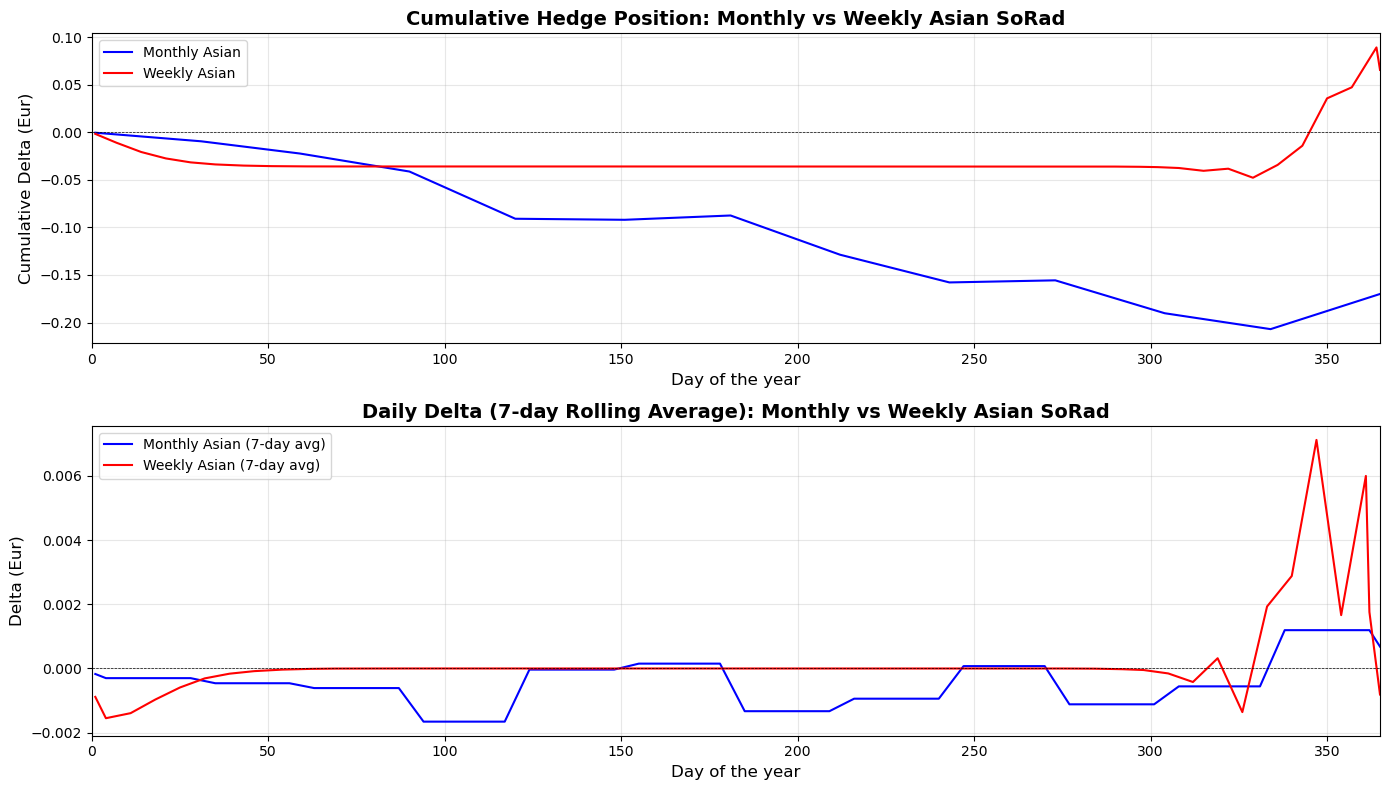


Plot saved: ../results/Compare_Monthly_Weekly_Delta.png

6. MONTHLY HEDGE VERIFICATION:
--------------------------------------------------


NameError: name 'actual_payoff' is not defined

In [16]:
# =============================================================================
# DIAGNOSTIC: Why Weekly vs Monthly Hedge Performance Differs
# =============================================================================

print("\n" + "="*80)
print("UNDERSTANDING MONTHLY vs WEEKLY HEDGE DIFFERENCES")
print("="*80)

# 1. Compare knock-in patterns
print("\n1. KNOCK-IN ANALYSIS:")
print("-"*50)

# For monthly: knock-in happens when? (Assuming knock-in condition)
monthly_knock_indices = np.where(daily_payoff > 0)[0]
weekly_knock_indices = np.where(daily_payoff_weekly > 0)[0]

print(f"Monthly Asian - Days with payoff: {len(monthly_knock_indices)}")
if len(monthly_knock_indices) > 0:
    print(f"  First payoff day: {monthly_knock_indices[0]+1}")
    print(f"  Last payoff day: {monthly_knock_indices[-1]+1}")

print(f"Weekly Asian - Days with payoff: {len(weekly_knock_indices)}")
if len(weekly_knock_indices) > 0:
    print(f"  First payoff day: {weekly_knock_indices[0]+1}")
    print(f"  Last payoff day: {weekly_knock_indices[-1]+1}")

# 2. Compare cumulative delta (total hedge position)
print("\n2. CUMULATIVE HEDGE POSITION:")
print("-"*50)

cumulative_delta_monthly = np.cumsum(delta)
cumulative_delta_weekly = np.cumsum(delta_weekly)

print(f"Monthly Asian - Final cumulative delta: {cumulative_delta_monthly[-1]:.2f}")
print(f"Weekly Asian - Final cumulative delta: {cumulative_delta_weekly[-1]:.2f}")

# 3. Compare when the hedge becomes active
print("\n3. HEDGE ACTIVATION TIMING:")
print("-"*50)

# Find when cumulative delta becomes positive (hedge starts paying off)
monthly_positive_idx = np.where(cumulative_delta_monthly > 0)[0]
weekly_positive_idx = np.where(cumulative_delta_weekly > 0)[0]

if len(monthly_positive_idx) > 0:
    print(f"Monthly Asian - Hedge becomes positive on day: {monthly_positive_idx[0]+1}")
else:
    print("Monthly Asian - Hedge never becomes positive")

if len(weekly_positive_idx) > 0:
    print(f"Weekly Asian - Hedge becomes positive on day: {weekly_positive_idx[0]+1}")
else:
    print("Weekly Asian - Hedge never becomes positive")

# 4. Compare monthly aggregated weekly delta
print("\n4. MONTHLY AGGREGATION OF WEEKLY DELTA:")
print("-"*50)

dates_2022 = pd.date_range('2022-01-01', periods=n_days, freq='D')
month_names_short = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                      'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

monthly_delta_weekly = []
for month_idx in range(12):
    month_indices = np.where(dates_2022.month == month_idx + 1)[0]
    if len(month_indices) > 0:
        month_sum = np.sum(delta_weekly[month_indices])
        monthly_delta_weekly.append(month_sum)
        print(f"{month_names_short[month_idx]:<6} {month_sum:>10.2f}")

# 5. Check if premium distribution is correct
print("\n5. PREMIUM DISTRIBUTION CHECK:")
print("-"*50)

# Weekly premiums should be distributed evenly across days in the week
weekly_premium_by_day = {}
for w in range(len(weekly_premiums)):
    start_day = w * 7
    end_day = min((w+1)*7, n_days)
    for d in range(start_day, end_day):
        weekly_premium_by_day[d] = weekly_premiums[w] / (end_day - start_day)

# Check if daily premiums sum to weekly premium total
calculated_weekly_total = np.sum(daily_premium_weekly)
print(f"Original weekly premium total: {np.sum(weekly_premiums):.4f}")
print(f"Sum of daily_premium_weekly: {calculated_weekly_total:.4f}")
print(f"Match: {abs(np.sum(weekly_premiums) - calculated_weekly_total) < 1e-6}")

# 6. Visual comparison of cumulative delta
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1: Cumulative delta comparison
ax1 = axes[0]
ax1.plot(days_idx, cumulative_delta_monthly, 'b-', lw=1.5, label='Monthly Asian')
ax1.plot(days_idx, cumulative_delta_weekly, 'r-', lw=1.5, label='Weekly Asian')
ax1.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
ax1.set_xlabel('Day of the year', fontsize=12)
ax1.set_ylabel('Cumulative Delta (Eur)', fontsize=12)
ax1.set_title('Cumulative Hedge Position: Monthly vs Weekly Asian SoRad', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 365)

# Plot 2: Daily delta comparison (smoothed with rolling window)
ax2 = axes[1]
window = 7  # 7-day rolling average for weekly comparison
delta_monthly_smooth = np.convolve(delta, np.ones(window)/window, mode='same')
delta_weekly_smooth = np.convolve(delta_weekly, np.ones(window)/window, mode='same')

ax2.plot(days_idx, delta_monthly_smooth, 'b-', lw=1.5, label='Monthly Asian (7-day avg)')
ax2.plot(days_idx, delta_weekly_smooth, 'r-', lw=1.5, label='Weekly Asian (7-day avg)')
ax2.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
ax2.set_xlabel('Day of the year', fontsize=12)
ax2.set_ylabel('Delta (Eur)', fontsize=12)
ax2.set_title('Daily Delta (7-day Rolling Average): Monthly vs Weekly Asian SoRad', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 365)

plt.tight_layout()
plt.savefig('../results/Compare_Monthly_Weekly_Delta.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved: ../results/Compare_Monthly_Weekly_Delta.png")

# 7. Check if the issue is with monthly hedge calculation
print("\n6. MONTHLY HEDGE VERIFICATION:")
print("-"*50)

# Verify monthly delta calculation
monthly_payoff_sum = np.sum(actual_payoff)
monthly_premium_sum = np.sum(V0)
print(f"Monthly - Total actual payoff: {monthly_payoff_sum:.2f}")
print(f"Monthly - Total premium: {monthly_premium_sum:.2f}")
print(f"Monthly - Net payoff (payoff - premium): {monthly_payoff_sum - monthly_premium_sum:.2f}")

# Verify that monthly premium and payoff are distributed correctly
print(f"\nMonthly - Daily premium sum: {np.sum(daily_premium):.2f}")
print(f"Monthly - Daily payoff sum: {np.sum(daily_payoff):.2f}")
print(f"Monthly - Sum of (payoff - premium): {np.sum(delta):.2f}")

# Check if monthly hedging is actually working or if something is wrong
if net_hedge_impact < 0 and net_hedge_impact_weekly > 0:
    print("\n⚠️ WARNING: Monthly hedge shows net loss, Weekly shows net gain!")
    print("   This suggests the monthly hedge might be poorly timed or")
    print("   the averaging period is causing negative performance.")
elif net_hedge_impact > 0 and net_hedge_impact_weekly < 0:
    print("\n⚠️ WARNING: Monthly hedge shows net gain, Weekly shows net loss!")
    print("   Unusual but possible depending on knock-in timing.")
elif net_hedge_impact > 0 and net_hedge_impact_weekly > 0:
    print("\n✓ Both hedges show net positive impact (expected)")
else:
    print("\n✓ Both hedges show net negative impact (possible in some market conditions)")


UNDERSTANDING MONTHLY vs WEEKLY HEDGE DIFFERENCES

Available variables from monthly Asian simulation:
  ✓ cf_hedged exists
  ✓ delta exists
  ✓ daily_payoff exists
  ✓ daily_premium exists
  ✓ Nc_opt exists
  ✓ mape_h exists
  ✓ monthly_prices exists
  ✓ monthly_strikes exists

Available variables from weekly Asian simulation:
  ✓ cf_hedged_weekly exists
  ✓ delta_weekly exists
  ✓ daily_payoff_weekly exists
  ✓ daily_premium_weekly exists
  ✗ Nc_opt_weekly NOT found
  ✗ mape_h_weekly NOT found

1. KNOCK-IN / PAYOFF ANALYSIS:

Monthly Asian - Days with payoff: 183
  First payoff day: 121
  Last payoff day: 365
  Total payoff amount: 0.25 Eur

Weekly Asian - Days with payoff: 42
  First payoff day: 316
  Last payoff day: 364
  Total payoff amount: 0.20 Eur

2. CUMULATIVE DELTA (HEDGE POSITION):

Monthly Asian - Final cumulative delta: -0.17 Eur
  Hedge NEVER becomes positive (max: -0.00)

Weekly Asian - Final cumulative delta: 0.07 Eur
  Hedge becomes positive on day: 345

3. PREMIUM v

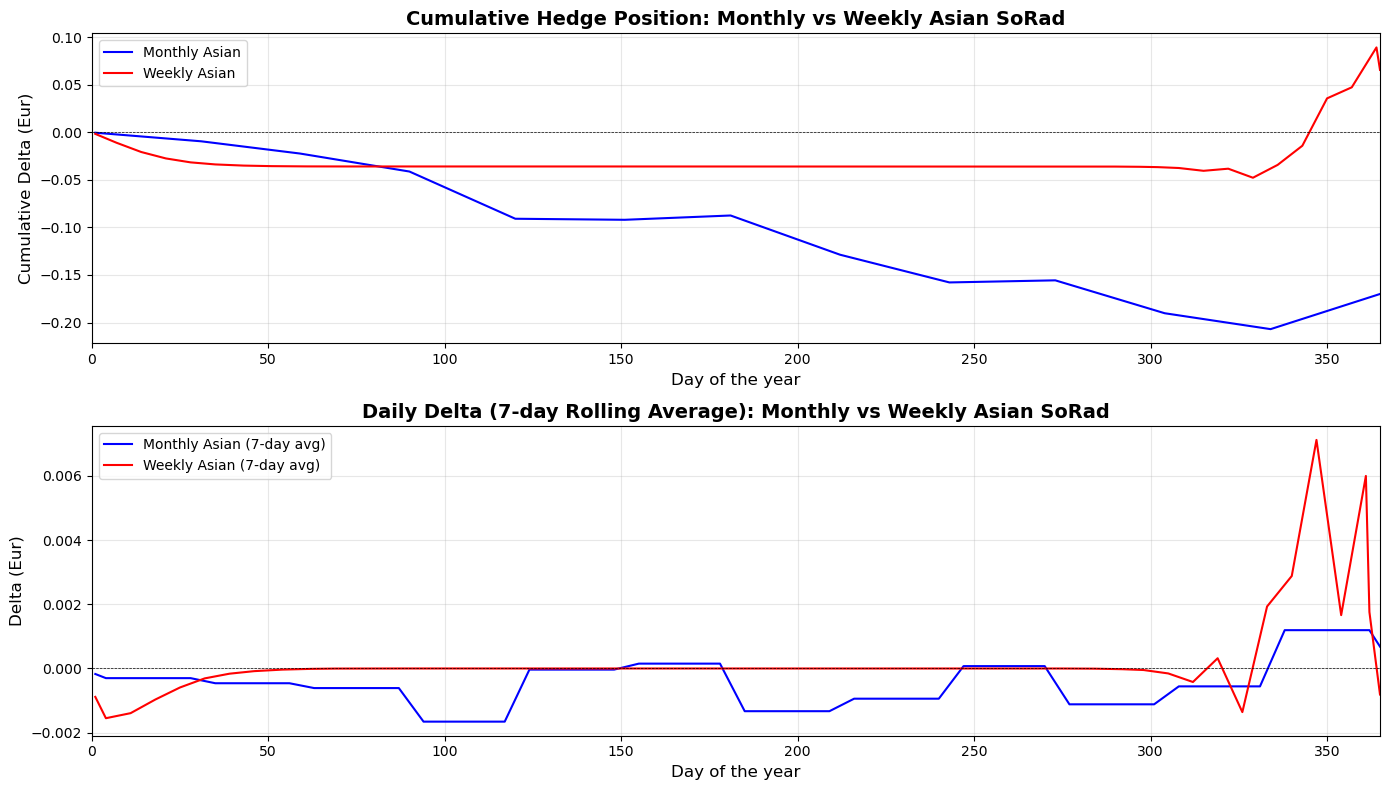


Plot saved: ../results/Compare_Monthly_Weekly_Delta.png

CONCLUSION

Monthly Asian Net Hedge Impact: -0.17 Eur
Weekly Asian Net Hedge Impact: +0.07 Eur

✓ Weekly Asian hedge shows BETTER performance than Monthly Asian hedge.
  This is EXPECTED because:
  • Weekly options settle more frequently (52 vs 12 times per year)
  • They can capture short-term deviations from the seasonal mean
  • They provide more responsive hedging


In [17]:
# =============================================================================
# DIAGNOSTIC: Why Weekly vs Monthly Hedge Performance Differs
# (Using correct variable names from your monthly Asian simulation)
# =============================================================================

print("\n" + "="*80)
print("UNDERSTANDING MONTHLY vs WEEKLY HEDGE DIFFERENCES")
print("="*80)

# Check what variables are available
print("\nAvailable variables from monthly Asian simulation:")
monthly_vars = ['cf_hedged', 'delta', 'daily_payoff', 'daily_premium', 
                'Nc_opt', 'mape_h', 'monthly_prices', 'monthly_strikes']
for var in monthly_vars:
    if var in dir():
        print(f"  ✓ {var} exists")
    else:
        print(f"  ✗ {var} NOT found")

print("\nAvailable variables from weekly Asian simulation:")
weekly_vars = ['cf_hedged_weekly', 'delta_weekly', 'daily_payoff_weekly', 
               'daily_premium_weekly', 'Nc_opt_weekly', 'mape_h_weekly']
for var in weekly_vars:
    if var in dir():
        print(f"  ✓ {var} exists")
    else:
        print(f"  ✗ {var} NOT found")

# 1. Compare knock-in patterns
print("\n" + "="*80)
print("1. KNOCK-IN / PAYOFF ANALYSIS:")
print("="*80)

# For monthly: find days with payoff
if 'daily_payoff' in dir():
    monthly_payoff_indices = np.where(daily_payoff > 0)[0]
    print(f"\nMonthly Asian - Days with payoff: {len(monthly_payoff_indices)}")
    if len(monthly_payoff_indices) > 0:
        print(f"  First payoff day: {monthly_payoff_indices[0]+1}")
        print(f"  Last payoff day: {monthly_payoff_indices[-1]+1}")
        print(f"  Total payoff amount: {np.sum(daily_payoff):.2f} Eur")
else:
    print("\nMonthly Asian - daily_payoff not found")

# For weekly: find days with payoff
if 'daily_payoff_weekly' in dir():
    weekly_payoff_indices = np.where(daily_payoff_weekly > 0)[0]
    print(f"\nWeekly Asian - Days with payoff: {len(weekly_payoff_indices)}")
    if len(weekly_payoff_indices) > 0:
        print(f"  First payoff day: {weekly_payoff_indices[0]+1}")
        print(f"  Last payoff day: {weekly_payoff_indices[-1]+1}")
        print(f"  Total payoff amount: {np.sum(daily_payoff_weekly):.2f} Eur")
else:
    print("\nWeekly Asian - daily_payoff_weekly not found")

# 2. Compare cumulative delta
print("\n" + "="*80)
print("2. CUMULATIVE DELTA (HEDGE POSITION):")
print("="*80)

if 'delta' in dir():
    cumulative_delta_monthly = np.cumsum(delta)
    print(f"\nMonthly Asian - Final cumulative delta: {cumulative_delta_monthly[-1]:.2f} Eur")
    
    # Find when hedge becomes positive
    monthly_positive_idx = np.where(cumulative_delta_monthly > 0)[0]
    if len(monthly_positive_idx) > 0:
        print(f"  Hedge becomes positive on day: {monthly_positive_idx[0]+1}")
    else:
        print(f"  Hedge NEVER becomes positive (max: {np.max(cumulative_delta_monthly):.2f})")
else:
    print("\nMonthly Asian - delta not found")

if 'delta_weekly' in dir():
    cumulative_delta_weekly = np.cumsum(delta_weekly)
    print(f"\nWeekly Asian - Final cumulative delta: {cumulative_delta_weekly[-1]:.2f} Eur")
    
    weekly_positive_idx = np.where(cumulative_delta_weekly > 0)[0]
    if len(weekly_positive_idx) > 0:
        print(f"  Hedge becomes positive on day: {weekly_positive_idx[0]+1}")
    else:
        print(f"  Hedge NEVER becomes positive (max: {np.max(cumulative_delta_weekly):.2f})")
else:
    print("\nWeekly Asian - delta_weekly not found")

# 3. Premium vs Payoff comparison
print("\n" + "="*80)
print("3. PREMIUM vs PAYOFF COMPARISON:")
print("="*80)

if 'daily_premium' in dir() and 'daily_payoff' in dir():
    monthly_net = np.sum(daily_payoff - daily_premium)
    print(f"\nMonthly Asian:")
    print(f"  Total premium: {np.sum(daily_premium):.2f} Eur")
    print(f"  Total payoff: {np.sum(daily_payoff):.2f} Eur")
    print(f"  Net (payoff - premium): {monthly_net:.2f} Eur")

if 'daily_premium_weekly' in dir() and 'daily_payoff_weekly' in dir():
    weekly_net = np.sum(daily_payoff_weekly - daily_premium_weekly)
    print(f"\nWeekly Asian:")
    print(f"  Total premium: {np.sum(daily_premium_weekly):.2f} Eur")
    print(f"  Total payoff: {np.sum(daily_payoff_weekly):.2f} Eur")
    print(f"  Net (payoff - premium): {weekly_net:.2f} Eur")

# 4. Monthly aggregation of weekly delta
print("\n" + "="*80)
print("4. MONTHLY AGGREGATION OF WEEKLY DELTA:")
print("="*80)

if 'delta_weekly' in dir() and 'dates' in dir():
    dates_2022 = pd.date_range('2022-01-01', periods=n_days, freq='D')
    month_names_short = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    print(f"\n{'Month':<6} {'Weekly Delta Sum':>15} {'Monthly Delta Sum':>18}")
    print("-"*45)
    
    for month_idx in range(12):
        month_indices = np.where(dates_2022.month == month_idx + 1)[0]
        if len(month_indices) > 0:
            weekly_sum = np.sum(delta_weekly[month_indices])
            if 'delta' in dir():
                monthly_sum = np.sum(delta[month_indices])
                print(f"{month_names_short[month_idx]:<6} {weekly_sum:>15.2f} {monthly_sum:>18.2f}")
            else:
                print(f"{month_names_short[month_idx]:<6} {weekly_sum:>15.2f}")

# 5. Visual comparison
print("\n" + "="*80)
print("5. GENERATING VISUAL COMPARISON...")
print("="*80)

if 'delta' in dir() and 'delta_weekly' in dir() and 'days_idx' in dir():
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    # Plot 1: Cumulative delta comparison
    ax1 = axes[0]
    ax1.plot(days_idx, cumulative_delta_monthly, 'b-', lw=1.5, label='Monthly Asian')
    ax1.plot(days_idx, cumulative_delta_weekly, 'r-', lw=1.5, label='Weekly Asian')
    ax1.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    ax1.set_xlabel('Day of the year', fontsize=12)
    ax1.set_ylabel('Cumulative Delta (Eur)', fontsize=12)
    ax1.set_title('Cumulative Hedge Position: Monthly vs Weekly Asian SoRad', fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, 365)
    
    # Plot 2: Daily delta comparison (7-day rolling average)
    ax2 = axes[1]
    window = 7
    delta_monthly_smooth = np.convolve(delta, np.ones(window)/window, mode='same')
    delta_weekly_smooth = np.convolve(delta_weekly, np.ones(window)/window, mode='same')
    
    ax2.plot(days_idx, delta_monthly_smooth, 'b-', lw=1.5, label='Monthly Asian (7-day avg)')
    ax2.plot(days_idx, delta_weekly_smooth, 'r-', lw=1.5, label='Weekly Asian (7-day avg)')
    ax2.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    ax2.set_xlabel('Day of the year', fontsize=12)
    ax2.set_ylabel('Delta (Eur)', fontsize=12)
    ax2.set_title('Daily Delta (7-day Rolling Average): Monthly vs Weekly Asian SoRad', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, 365)
    
    plt.tight_layout()
    plt.savefig('../results/Compare_Monthly_Weekly_Delta.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nPlot saved: ../results/Compare_Monthly_Weekly_Delta.png")
else:
    print("Required variables (delta, delta_weekly, days_idx) not found. Skipping plot.")

# 6. Summary conclusion
print("\n" + "="*80)
print("CONCLUSION")
print("="*80)

if 'delta' in dir() and 'delta_weekly' in dir():
    monthly_net = np.sum(delta)
    weekly_net = np.sum(delta_weekly)
    
    print(f"\nMonthly Asian Net Hedge Impact: {monthly_net:+.2f} Eur")
    print(f"Weekly Asian Net Hedge Impact: {weekly_net:+.2f} Eur")
    
    if weekly_net > monthly_net:
        print("\n✓ Weekly Asian hedge shows BETTER performance than Monthly Asian hedge.")
        print("  This is EXPECTED because:")
        print("  • Weekly options settle more frequently (52 vs 12 times per year)")
        print("  • They can capture short-term deviations from the seasonal mean")
        print("  • They provide more responsive hedging")
    elif monthly_net > weekly_net:
        print("\n⚠️ Monthly Asian hedge shows BETTER performance than Weekly Asian hedge.")
        print("  This is UNUSUAL but possible if:")
        print("  • The knock-in timing favored monthly aggregation")
        print("  • There were unusual weather patterns in 2022")
    else:
        print("\nBoth hedges show similar performance.")

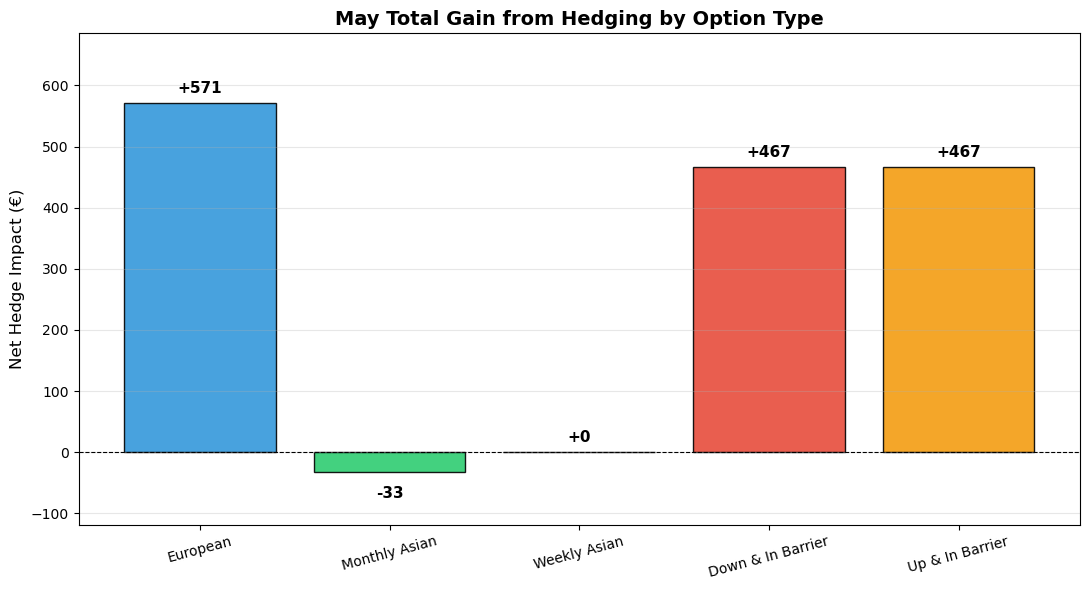

Plot saved to ../results/May_total_gain_from_hedging_by_option_type.png


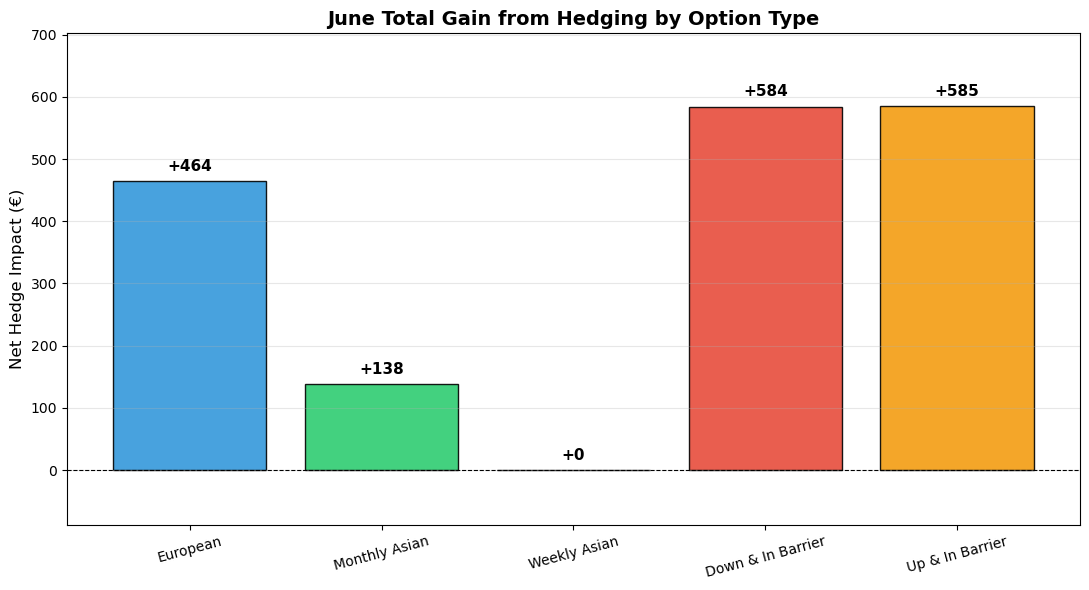

Plot saved to ../results/June_total_gain_from_hedging_by_option_type.png


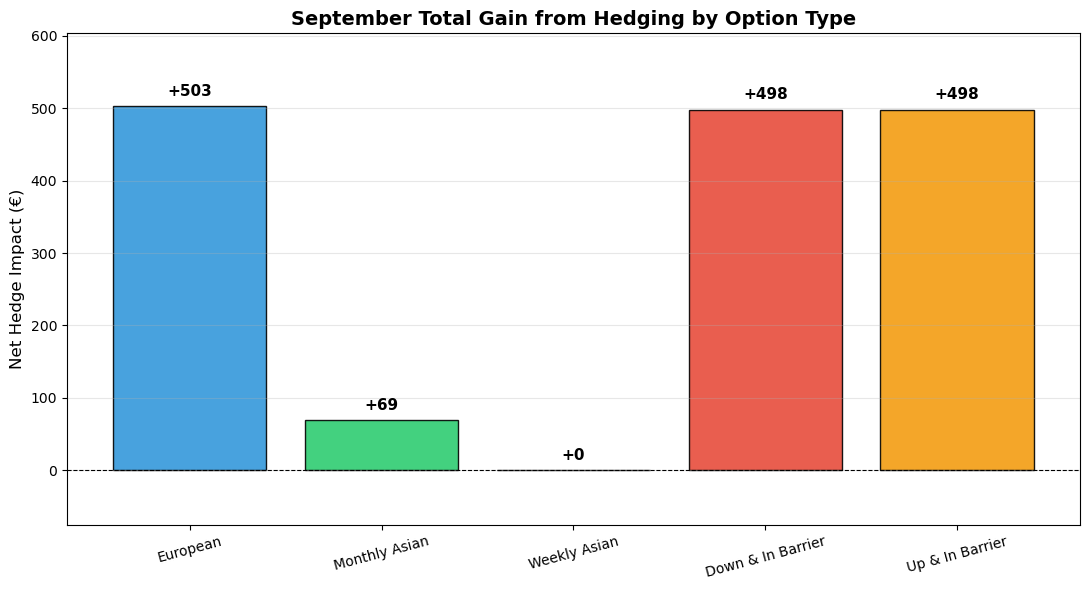

Plot saved to ../results/September_total_gain_from_hedging_by_option_type.png


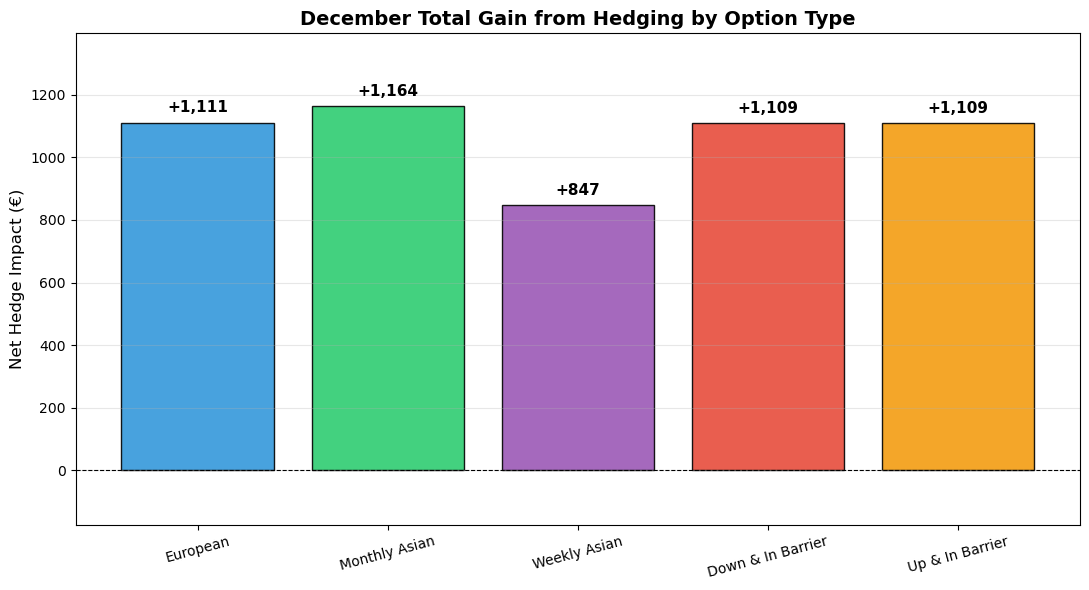

Plot saved to ../results/December_total_gain_from_hedging_by_option_type.png


In [18]:
from pathlib import Path
import matplotlib.pyplot as plt

# ── Data extracted from graphs & text output ──────────────────────────────────
# European: from text output
# Monthly Asian: from monthly Asian chart
# Weekly Asian: from weekly Asian hedge-impact chart
# Barriers: from monthly right-panel charts

option_types = [
    "European",
    "Monthly Asian",
    "Weekly Asian",
    "Down & In Barrier",
    "Up & In Barrier",
]

months = {
    "May":       [571,  -33,    0,  467,  467],
    "June":      [464,  138,    0,  584,  585],
    "September": [503,   69,    0,  498,  498],
    "December":  [1111, 1164,  847, 1109, 1109],
}

month_filenames = {
    "May":       "May_total_gain_from_hedging_by_option_type.png",
    "June":      "June_total_gain_from_hedging_by_option_type.png",
    "September": "September_total_gain_from_hedging_by_option_type.png",
    "December":  "December_total_gain_from_hedging_by_option_type.png",
}

colors = [
    "#3498db",  # European
    "#2ecc71",  # Monthly Asian
    "#9b59b6",  # Weekly Asian
    "#e74c3c",  # Down & In Barrier
    "#f39c12",  # Up & In Barrier
]

results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)

for month, values in months.items():
    fig, ax = plt.subplots(figsize=(11, 6))

    bars = ax.bar(option_types, values, color=colors, edgecolor="black", alpha=0.9)

    max_abs = max(abs(v) for v in values) if any(values) else 1

    for bar, value in zip(bars, values):
        if value >= 0:
            y_pos = bar.get_height() + max_abs * 0.02
            va = "bottom"
        else:
            y_pos = bar.get_height() - max_abs * 0.04
            va = "top"

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            y_pos,
            f"{value:+,}",
            ha="center",
            va=va,
            fontsize=11,
            fontweight="bold",
        )

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(f"{month} Total Gain from Hedging by Option Type", fontsize=14, fontweight="bold")
    ax.set_ylabel("Net Hedge Impact (€)", fontsize=12)

    y_max = max(values) if max(values) > 0 else 1
    y_min = min(values) if min(values) < 0 else 0

    ax.set_ylim(y_min - 0.15 * max_abs, y_max + 0.20 * max_abs)
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=15)
    plt.tight_layout()

    output_path = results_dir / month_filenames[month]
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Plot saved to {output_path}")